In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
data=pd.read_csv('village_restro.csv')

In [ ]:
data

,title,url,stars,name,reviewUrl,text
0,Village Restaurant,https://www.google.com/maps/search/?api=1&quer...,4,NaN,NaN,NaN
1,Village Restaurant,https://www.google.com/maps/search/?api=1&quer...,5,NaN,NaN,Had a wonderful experience at this restaurant!...
2,Village Restaurant,https://www.google.com/maps/search/?api=1&quer...,4,NaN,NaN,NaN
3,Village Restaurant,https://www.google.com/maps/search/?api=1&quer...,5,NaN,NaN,"I had vegetarian meal there, Taste was good, a..."
4,Village Restaurant,https://www.google.com/maps/search/?api=1&quer...,1,NaN,NaN,Had been there after a hectic flight and was e...
...,...,...,...,...,...,...
7932,Village Restaurant,https://www.google.com/maps/search/?api=1&quer...,5,NaN,NaN,NaN
7933,Village Restaurant,https://www.google.com/maps/search/?api=1&quer...,5,NaN,NaN,NaN
7934,Village Restaurant,https://www.google.com/maps/search/?api=1&quer...,5,NaN,NaN,NaN
7935,Village Restaurant,https://www.google.com/maps/search/?api=1&quer...,5,NaN,NaN,Crowded but a very popular and nice hangout


In [ ]:
data.shape

(7937, 6)

In [ ]:
data.isnull().mean()

,0
title,0.000000
url,0.000000
stars,0.000000
name,1.000000
reviewUrl,1.000000
text,0.545798


In [ ]:
data=data.drop(columns=['name','reviewUrl','url','title'])

In [ ]:
data

,stars,text
0,4,NaN
1,5,Had a wonderful experience at this restaurant!...
2,4,NaN
3,5,"I had vegetarian meal there, Taste was good, a..."
4,1,Had been there after a hectic flight and was e...
...,...,...
7932,5,NaN
7933,5,NaN
7934,5,NaN
7935,5,Crowded but a very popular and nice hangout


In [ ]:
data['stars'].isnull().sum()
# no null values in 'stars' column

np.int64(0)

In [ ]:
data['stars'].value_counts(normalize=True)*100

,proportion
stars,
5,57.074461
4,23.951115
1,8.113897
3,7.496535
2,3.363991


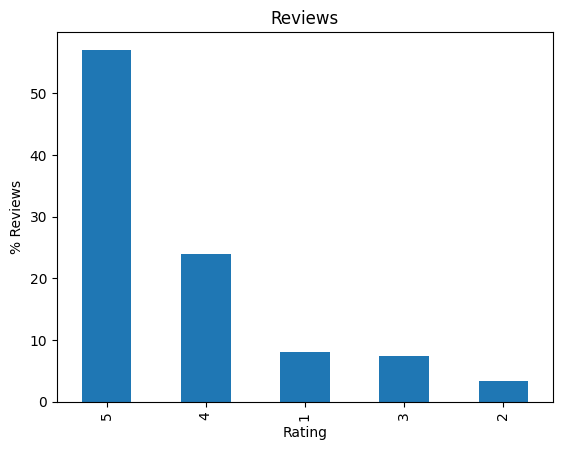

In [ ]:
(data['stars'].value_counts(normalize=True)*100).plot(kind='bar')
plt.title('Reviews')
plt.ylabel('% Reviews')
plt.xlabel('Rating')
plt.show()

In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob

In [ ]:
data=data.dropna()

In [ ]:
df=pd.DataFrame(data=data['text'])

In [ ]:
df.head(5)

,text
1,Had a wonderful experience at this restaurant!...
3,"I had vegetarian meal there, Taste was good, a..."
4,Had been there after a hectic flight and was e...
5,Anjal Fish frozen\nOnly dragon chicken was goo...
6,Huge family restaurant. But good baby seats n...


In [ ]:
df.shape

(3605, 1)

In [ ]:
df['text'].str.lower()

,text
1,had a wonderful experience at this restaurant!...
3,"i had vegetarian meal there, taste was good, a..."
4,had been there after a hectic flight and was e...
5,anjal fish frozen\nonly dragon chicken was goo...
6,huge family restaurant. but good baby seats n...
...,...
7921,great ambience with great taste with very vast...
7922,good ambience and cozy. seems to be quite popu...
7925,we didn’t like today’s service of the steward ...
7926,we are regular visitors of this restaurant. we...


In [ ]:
# Lowercasing
def lowercase(text):
  return text.lower()

In [ ]:
df['text']=df['text'].apply(lowercase)

In [ ]:
import string
punctuations=string.punctuation

In [ ]:
punctuations

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
def punc(text):
  return text.translate(str.maketrans('','',punctuations))

In [ ]:
#removing Punctuation
df['text']=df['text'].apply(lambda x: ''.join(char for char in str(x) if char not in punctuations))

In [ ]:
# removing numbers
df['text']=df['text'].apply(lambda x: ''.join(num for num in x if not num.isdigit()))

In [ ]:
# removing html tags
import re
def striphtml(data):
  p=re.compile(r'<.*?>')
  return p.sub('',data)

In [ ]:
df['text']=df['text'].apply(striphtml)

In [ ]:
# removing emoji
df['text'].apply(lambda x: ''.join(char for char in x if char.isascii()))

,text
1,had a wonderful experience at this restaurant ...
3,i had vegetarian meal there taste was good amb...
4,had been there after a hectic flight and was e...
5,anjal fish frozen\nonly dragon chicken was goo...
6,huge family restaurant but good baby seats no...
...,...
7921,great ambience with great taste with very vast...
7922,good ambience and cozy seems to be quite popul...
7925,we didnt like todays service of the steward an...
7926,we are regular visitors of this restaurant we ...


In [ ]:
!pip install emoji


In [ ]:
import emoji

In [ ]:
def emo(text):
  return emoji.demojize(text)

In [ ]:
df['text']=df['text'].apply(emo)

In [ ]:
#Removing stopwords
import nltk
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stopwords=stopwords.words('english')

In [ ]:
df['text']=df['text'].apply(lambda x: ' '.join(words for words in x.split() if words not in stopwords))

In [ ]:
# Strip
df['text']=df['text'].str.strip()

In [ ]:
df.head(5)

,text
1,wonderful experience restaurant food delicious...
3,vegetarian meal taste good ambient good
4,hectic flight extremely hungry reached restaur...
5,anjal fish frozen dragon chicken good mixed fr...
6,huge family restaurant good baby seats availab...


Sentiment Analysis

In [ ]:
def sentiment_text(text):
  analysis=TextBlob(text)
  if analysis.sentiment.polarity>0:
    return "Positive"
  elif analysis.sentiment.polarity<0:
    return "Negative"
  else:
    return "Neutral"

In [ ]:
df['Sentiment']=df['text'].apply(sentiment_text)

In [ ]:
df['Sentiment'].value_counts()

,count
Sentiment,
Positive,2874
Negative,483
Neutral,248


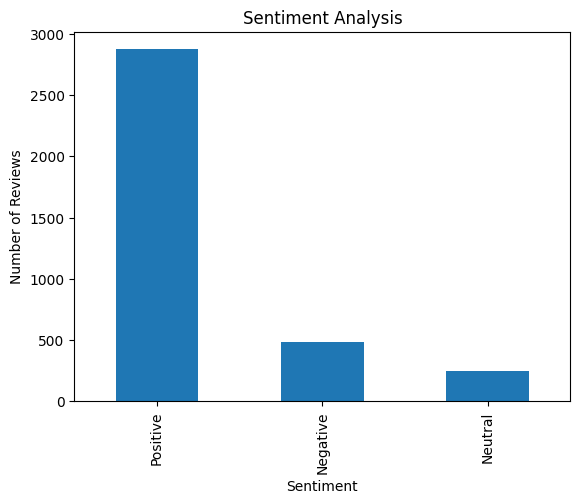

In [ ]:
df['Sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Analysis')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

#Tokenization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf=TfidfVectorizer()

In [ ]:
x=tfidf.fit_transform(df['text']).toarray()

In [ ]:
print(tfidf.idf_)

[8.49720722 8.49720722 8.49720722 ... 8.49720722 8.49720722 8.49720722]


In [ ]:
print(tfidf.get_feature_names_out())

['aaaaamazinggggg' 'aapke' 'aapki' ... 'ವರ' 'ವಲ' '良かったです']


Machine Learning

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le=LabelEncoder()

In [ ]:
y=le.fit_transform(df['Sentiment'])

In [ ]:
lr=LogisticRegression()

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
lr.fit(x_train,y_train)

LogisticRegression()

In [ ]:
pred=lr.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
accuracy_score(y_test,pred)

0.9029126213592233